<a href="https://colab.research.google.com/github/Double-El/future_academy/blob/supervised/supervised.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving profiles.xlsx to profiles (1).xlsx


In [ ]:
import pandas as pd

df = pd.read_excel('profiles.xlsx')

df.head()

,employee_id,name,branch,position,position_group,gender,age,years_at_company,performance_score,last_promotion_year,customer_satisfaction_avg,num_handled_complaints,leadership_score,team_size,is_mentor
0,H001,구민준,Tech운영부,대리,중간 관리자,여,34,4,98,2020,5.0,12,93.0,NaN,True
1,H002,김수진,글로벌서비스개발부,행원,실무자,남,27,2,94,2019,4.8,30,NaN,NaN,False
2,H003,김애은,금융서비스개발부,행원,실무자,남,30,1,98,2020,4.4,44,NaN,NaN,False
3,H004,김여리,Tech운영부,행원,실무자,여,25,2,72,2022,5.0,16,NaN,NaN,False
4,H005,김연지,자금세탁방지부,대리,중간 관리자,남,32,5,76,2021,3.9,36,79.0,NaN,True


In [ ]:
print(df.columns[:30])

Index(['employee_id', 'name', 'branch', 'position', 'position_group', 'gender',
       'age', 'years_at_company', 'performance_score', 'last_promotion_year',
       'customer_satisfaction_avg', 'num_handled_complaints',
       'leadership_score', 'team_size', 'is_mentor'],
      dtype='object')


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving df_final.xlsx to df_final (2).xlsx


In [ ]:
df_final = pd.read_excel('df_final.xlsx')

df_final[['name', 'cluster']][:10]

,name,cluster
0,구민준,3
1,김수진,6
2,김애은,5
3,김여리,4
4,김연지,2
5,김영서,0
6,김윤지,1
7,김준형,7
8,김진종,3
9,김희진,6


In [ ]:
# 정답이 있는 데이터셋으로 변모

df_final = pd.read_excel('df_final.xlsx', usecols=['name', 'cluster'])

df_merged = pd.merge(df, df_final, on='name', how='left')

df_merged.head()

,employee_id,name,branch,position,position_group,gender,age,years_at_company,performance_score,last_promotion_year,customer_satisfaction_avg,num_handled_complaints,leadership_score,team_size,is_mentor,cluster
0,H001,구민준,Tech운영부,대리,중간 관리자,여,34,4,98,2020,5.0,12,93.0,NaN,True,3
1,H002,김수진,글로벌서비스개발부,행원,실무자,남,27,2,94,2019,4.8,30,NaN,NaN,False,6
2,H003,김애은,금융서비스개발부,행원,실무자,남,30,1,98,2020,4.4,44,NaN,NaN,False,5
3,H004,김여리,Tech운영부,행원,실무자,여,25,2,72,2022,5.0,16,NaN,NaN,False,4
4,H005,김연지,자금세탁방지부,대리,중간 관리자,남,32,5,76,2021,3.9,36,79.0,NaN,True,2


In [ ]:
df_merged.columns

Index(['employee_id', 'name', 'branch', 'position', 'position_group', 'gender',
       'age', 'years_at_company', 'performance_score', 'last_promotion_year',
       'customer_satisfaction_avg', 'num_handled_complaints',
       'leadership_score', 'team_size', 'is_mentor', 'cluster'],
      dtype='object')

In [ ]:
df = df_merged[[ 'position', 'position_group', 'gender',
       'age', 'years_at_company', 'performance_score', 'last_promotion_year',
       'customer_satisfaction_avg', 'num_handled_complaints',
       'leadership_score', 'team_size', 'is_mentor', 'cluster']]
df.head()

,position,position_group,gender,age,years_at_company,performance_score,last_promotion_year,customer_satisfaction_avg,num_handled_complaints,leadership_score,team_size,is_mentor,cluster
0,대리,중간 관리자,여,34,4,98,2020,5.0,12,93.0,NaN,True,3
1,행원,실무자,남,27,2,94,2019,4.8,30,NaN,NaN,False,6
2,행원,실무자,남,30,1,98,2020,4.4,44,NaN,NaN,False,5
3,행원,실무자,여,25,2,72,2022,5.0,16,NaN,NaN,False,4
4,대리,중간 관리자,남,32,5,76,2021,3.9,36,79.0,NaN,True,2


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37 entries, 0 to 36
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   position                   37 non-null     object 
 1   position_group             37 non-null     object 
 2   gender                     37 non-null     object 
 3   age                        37 non-null     int64  
 4   years_at_company           37 non-null     int64  
 5   performance_score          37 non-null     int64  
 6   last_promotion_year        37 non-null     int64  
 7   customer_satisfaction_avg  37 non-null     float64
 8   num_handled_complaints     37 non-null     int64  
 9   leadership_score           21 non-null     float64
 10  team_size                  5 non-null      float64
 11  is_mentor                  37 non-null     bool   
 12  cluster                    37 non-null     int64  
dtypes: bool(1), float64(3), int64(6), object(3)
memory u

In [ ]:
# 앞서 position과 높은 상관관계 보여준 컬럼 삭제
df.drop(['position_group'], axis=1, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37 entries, 0 to 36
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   position                   37 non-null     object 
 1   gender                     37 non-null     object 
 2   age                        37 non-null     int64  
 3   years_at_company           37 non-null     int64  
 4   performance_score          37 non-null     int64  
 5   last_promotion_year        37 non-null     int64  
 6   customer_satisfaction_avg  37 non-null     float64
 7   num_handled_complaints     37 non-null     int64  
 8   leadership_score           21 non-null     float64
 9   team_size                  5 non-null      float64
 10  is_mentor                  37 non-null     bool   
 11  cluster                    37 non-null     int64  
dtypes: bool(1), float64(3), int64(6), object(2)
memory usage: 3.3+ KB


<ipython-input-10-4470ce84f56d>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(['position_group'], axis=1, inplace=True)


In [ ]:
# gender 자료 one_hot_encoding
df = pd.get_dummies(df, columns=['gender'], drop_first=False, dtype=int) # int미지정시 boolean자료로 나옴
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37 entries, 0 to 36
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   position                   37 non-null     object 
 1   age                        37 non-null     int64  
 2   years_at_company           37 non-null     int64  
 3   performance_score          37 non-null     int64  
 4   last_promotion_year        37 non-null     int64  
 5   customer_satisfaction_avg  37 non-null     float64
 6   num_handled_complaints     37 non-null     int64  
 7   leadership_score           21 non-null     float64
 8   team_size                  5 non-null      float64
 9   is_mentor                  37 non-null     bool   
 10  cluster                    37 non-null     int64  
 11  gender_남                   37 non-null     int64  
 12  gender_여                   37 non-null     int64  
dtypes: bool(1), float64(3), int64(8), object(1)
memory u

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37 entries, 0 to 36
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   position                   37 non-null     object 
 1   age                        37 non-null     int64  
 2   years_at_company           37 non-null     int64  
 3   performance_score          37 non-null     int64  
 4   last_promotion_year        37 non-null     int64  
 5   customer_satisfaction_avg  37 non-null     float64
 6   num_handled_complaints     37 non-null     int64  
 7   leadership_score           21 non-null     float64
 8   team_size                  5 non-null      float64
 9   is_mentor                  37 non-null     bool   
 10  cluster                    37 non-null     int64  
 11  gender_남                   37 non-null     int64  
 12  gender_여                   37 non-null     int64  
dtypes: bool(1), float64(3), int64(8), object(1)
memory u

In [ ]:
df = df.rename(columns={'gender_여': 'gender_female', 'gender_남': 'gender_male'})
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37 entries, 0 to 36
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   position                   37 non-null     object 
 1   age                        37 non-null     int64  
 2   years_at_company           37 non-null     int64  
 3   performance_score          37 non-null     int64  
 4   last_promotion_year        37 non-null     int64  
 5   customer_satisfaction_avg  37 non-null     float64
 6   num_handled_complaints     37 non-null     int64  
 7   leadership_score           21 non-null     float64
 8   team_size                  5 non-null      float64
 9   is_mentor                  37 non-null     bool   
 10  cluster                    37 non-null     int64  
 11  gender_male                37 non-null     int64  
 12  gender_female              37 non-null     int64  
dtypes: bool(1), float64(3), int64(8), object(1)
memory u

In [ ]:
# 직급 순서를 낮은 순 → 높은 순으로 정렬
rank_order = ['행원', '대리', '과장', '차장']
df['position'] = pd.Categorical(df['position'], categories=rank_order, ordered=True)

df['position'] = df['position'].cat.codes # 순서형 카테로기를 수치형으로 변환
df['position'].unique()

array([1, 0, 2, 3], dtype=int8)

In [ ]:
# bool자료형을 int로 변환
df['is_mentor'] = df['is_mentor'].replace({True: 1, False: 0})
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37 entries, 0 to 36
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   position                   37 non-null     int8   
 1   age                        37 non-null     int64  
 2   years_at_company           37 non-null     int64  
 3   performance_score          37 non-null     int64  
 4   last_promotion_year        37 non-null     int64  
 5   customer_satisfaction_avg  37 non-null     float64
 6   num_handled_complaints     37 non-null     int64  
 7   leadership_score           21 non-null     float64
 8   team_size                  5 non-null      float64
 9   is_mentor                  37 non-null     int64  
 10  cluster                    37 non-null     int64  
 11  gender_male                37 non-null     int64  
 12  gender_female              37 non-null     int64  
dtypes: float64(3), int64(9), int8(1)
memory usage: 3.6 K

<ipython-input-15-7e8f29db9cda>:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['is_mentor'] = df['is_mentor'].replace({True: 1, False: 0})


In [ ]:
missing_cols = df.columns[df.isnull().any()].tolist()
print(" 결측치가 있는 컬럼:", missing_cols)

 결측치가 있는 컬럼: ['leadership_score', 'team_size']


In [ ]:
df.columns

Index(['position', 'age', 'years_at_company', 'performance_score',
       'last_promotion_year', 'customer_satisfaction_avg',
       'num_handled_complaints', 'leadership_score', 'team_size', 'is_mentor',
       'cluster', 'gender_male', 'gender_female'],
      dtype='object')

In [ ]:
# 결측치가 있는 컬럼을 다른 특성을 고려한 다변량 대치법(MICE)로 채운다.
# 참고하고자 하는 컬럼은 모두 지정하였으나 target은 제외
target_cols = ['leadership_score', 'team_size']  # 결측치를 채우고 싶은 컬럼
ref_cols = ['position', 'age', 'years_at_company', 'performance_score',
       'last_promotion_year', 'customer_satisfaction_avg',
       'num_handled_complaints', 'is_mentor','gender_male', 'gender_female']  # 참고할 컬럼


# 대치에 사용할 전체 컬럼 리스트 (순서 중요 없음)
all_cols = ref_cols + target_cols

# 선택한 컬럼으로 구성된 서브 DataFrame
impute_df = df[all_cols]

# Iterative Imputer 정의 (회귀 기반)
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor

imputer = IterativeImputer(
    estimator=RandomForestRegressor(),
    max_iter=10,
    random_state=42
)

# 대치 실행
imputed_result = imputer.fit_transform(impute_df)

# DataFrame으로 변환
imputed_df = pd.DataFrame(imputed_result, columns=all_cols)

# 대치된 값만 원래 df에 반영
for col in target_cols:
    df[col] = imputed_df[col]

# 확인
print("결측치 처리 완료 여부:")
print(df[target_cols].isnull().sum())

결측치 처리 완료 여부:
leadership_score    0
team_size           0
dtype: int64


/usr/local/lib/python3.11/dist-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37 entries, 0 to 36
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   position                   37 non-null     int8   
 1   age                        37 non-null     int64  
 2   years_at_company           37 non-null     int64  
 3   performance_score          37 non-null     int64  
 4   last_promotion_year        37 non-null     int64  
 5   customer_satisfaction_avg  37 non-null     float64
 6   num_handled_complaints     37 non-null     int64  
 7   leadership_score           37 non-null     float64
 8   team_size                  37 non-null     float64
 9   is_mentor                  37 non-null     int64  
 10  cluster                    37 non-null     int64  
 11  gender_male                37 non-null     int64  
 12  gender_female              37 non-null     int64  
dtypes: float64(3), int64(9), int8(1)
memory usage: 3.6 K

Fitting 3 folds for each of 8 candidates, totalling 24 fits


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:51:31] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:51:31] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:51:31] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:51:31] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:51:31] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e

 Best Model:
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_class=8, num_parallel_tree=None, ...)

 Classification Report:
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00  

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


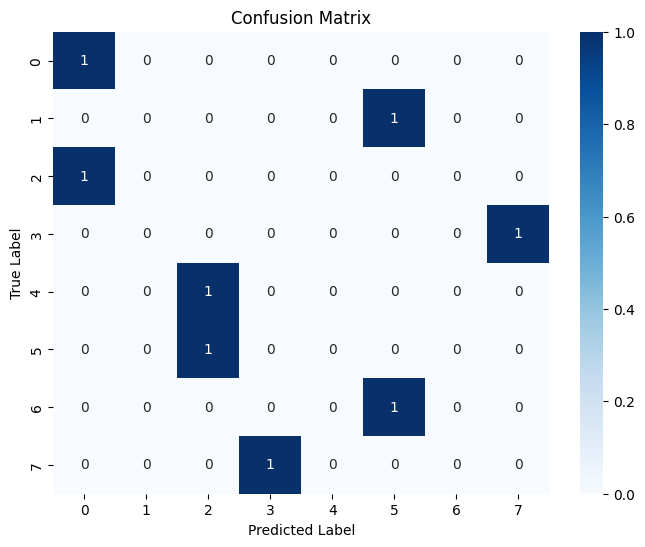

In [ ]:
# 다중클래스 타겟 예측을 위한 분류 모델 파이프라인 생성
# 앙상블, 부스팅, 하이퍼파라미터 튜징, 모델 평가 포함

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 준비
X = df.drop(columns='cluster')  # 입력 피처
y = df['cluster']               # 다중 클래스 타겟

# 범주형 변수 인코딩 + 수치형 스케일링
X = pd.get_dummies(X)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. 학습/테스트 분할
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# 3. 모델 정의
models = {
    'RandomForest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(
        objective='multi:softprob',
        num_class=len(np.unique(y)),
        use_label_encoder=False,
        eval_metric='mlogloss',
        random_state=42
    )
}

# 4. XGBoost 하이퍼파라미터 튜닝
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1]
}

grid = GridSearchCV(models['XGBoost'], param_grid, cv=3, scoring='f1_macro', verbose=1)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
print(f" Best Model:\n{best_model}")

# 5. 예측 및 평가
y_pred = best_model.predict(X_test)

print("\n Classification Report:")
print(classification_report(y_test, y_pred))

print(f" Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f" Macro F1-score: {f1_score(y_test, y_pred, average='macro'):.4f}")

# 6. Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


 클래스 분포:
cluster
3    5
6    5
5    5
4    5
2    5
0    4
1    4
7    4
Name: count, dtype: int64
Fitting 4 folds for each of 72 candidates, totalling 288 fits


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=4.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:52:16] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{me


 Best Model: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.2, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_class=8, num_parallel_tree=None, ...)

 Classification Report:
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00   

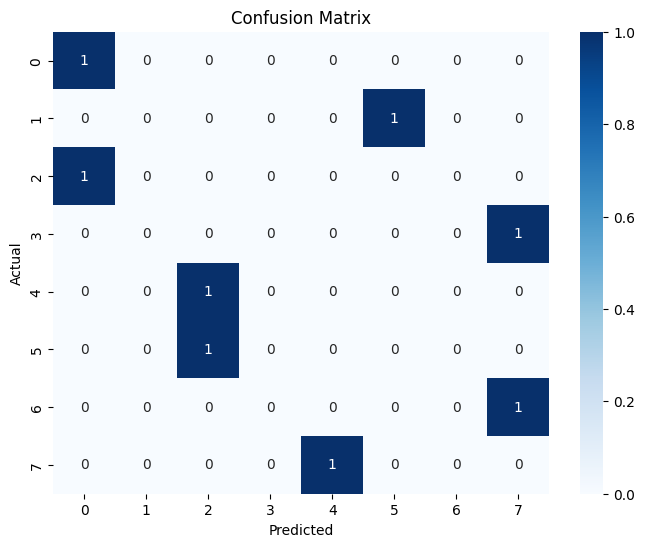

In [ ]:
# Accuracy: 0.1250 and Macro F1-score: 0.1250
# 랜덤 추측한 결과와 같으며, 실패한 원인은 다음과 같음.
# 모델 학습 실패, 데이터 부족, 클래스 불균형, 하이퍼파라미터 부적절

# 클래스 분포 확인
print(" 클래스 분포:")
print(y.value_counts())

from sklearn.model_selection import StratifiedKFold, GridSearchCV

# 모델 튜닝: XGBoost (범위 확대)
xgb = XGBClassifier(
    objective='multi:softprob',
    num_class=len(np.unique(y)),
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42
)

param_grid = {
    'n_estimators': [100, 300],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)
grid = GridSearchCV(xgb, param_grid, cv=cv, scoring='f1_macro', verbose=1, n_jobs=-1)

grid.fit(X_train, y_train)
best_model = grid.best_estimator_
print(f"\n Best Model: {best_model}")

# 예측 및 평가
y_pred = best_model.predict(X_test)

print("\n Classification Report:")
print(classification_report(y_test, y_pred))

print(f" Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f" Macro F1-score: {f1_score(y_test, y_pred, average='macro'):.4f}")

# Confusion Matrix 시각화
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
# 성과 개선이 없어서 적은 데이터에서도 잘 작동하는 KNN, NaiveBayes, LightGBM으로 진행

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=2)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

print(" KNN 결과")
print(classification_report(y_test, y_pred_knn))
print(f"KNN F1_macro: {f1_score(y_test, y_pred_knn, average='macro'):.4f}")


 KNN 결과
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         1
           3       1.00      1.00      1.00         1
           4       0.00      0.00      0.00         1
           5       0.00      0.00      0.00         1
           6       0.00      0.00      0.00         1
           7       0.00      0.00      0.00         1

    accuracy                           0.12         8
   macro avg       0.12      0.12      0.12         8
weighted avg       0.12      0.12      0.12         8

KNN F1_macro: 0.1250


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

print(" Naive Bayes 결과")
print(classification_report(y_test, y_pred_nb))
print(f"NB F1_macro: {f1_score(y_test, y_pred_nb, average='macro'):.4f}")


 Naive Bayes 결과
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         1
           3       0.25      1.00      0.40         1
           4       0.00      0.00      0.00         1
           5       0.00      0.00      0.00         1
           6       0.00      0.00      0.00         1
           7       0.00      0.00      0.00         1

    accuracy                           0.12         8
   macro avg       0.03      0.12      0.05         8
weighted avg       0.03      0.12      0.05         8

NB F1_macro: 0.0500


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from lightgbm import LGBMClassifier

lgb = LGBMClassifier(
    objective='multiclass',
    num_class=len(np.unique(y)),
    random_state=42
)
lgb.fit(X_train, y_train)
y_pred_lgb = lgb.predict(X_test)

print(" LightGBM 결과")
print(classification_report(y_test, y_pred_lgb))
print(f"LightGBM F1_macro: {f1_score(y_test, y_pred_lgb, average='macro'):.4f}")


[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 29, number of used features: 0
[LightGBM] [Info] Start training from score -2.268684
[LightGBM] [Info] Start training from score -2.268684
[LightGBM] [Info] Start training from score -1.981001
[LightGBM] [Info] Start training from score -1.981001
[LightGBM] [Info] Start training from score -1.981001
[LightGBM] [Info] Start training from score -1.981001
[LightGBM] [Info] Start training from score -1.981001
[LightGBM] [Info] Start training from score -2.268684
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] S

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitali

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47084 (\N{HANGUL SYLLABLE REO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr

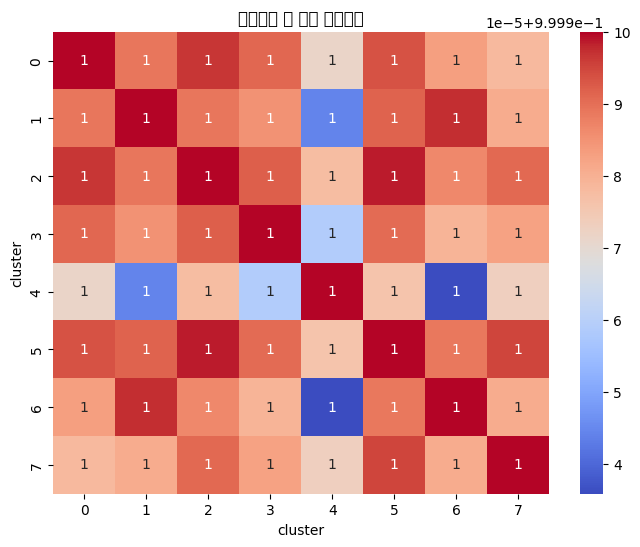

In [ ]:
# 데이터 수가 37개에 불과하나 클래스가 8개로 많음
# 오버피팅 위험성 높으며, 클래스 불균형에 따른 소수 클래스 무시될 수 있음.
# 각 클래스의 평균 특성을 비교하여 유사한 것끼리 묶기

# 군집별 평균값 보기
summary = df.groupby('cluster').mean(numeric_only=True)

# 상관관계 히트맵으로 시각화
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(summary.T.corr(), annot=True, cmap='coolwarm')
plt.title("클러스터 간 특성 상관관계")
plt.show()



In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import AgglomerativeClustering
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 클래스별 평균 벡터 생성
cluster_means = df.groupby('cluster').mean(numeric_only=True)

# 2. 정규화
scaler = StandardScaler()
scaled = scaler.fit_transform(cluster_means)

# 3. 코사인 유사도 계산
cos_sim = cosine_similarity(scaled)

# 4. 유사도 → 거리로 변환 (1 - 유사도)
cos_dist = 1 - cos_sim

# 5. 계층적 군집 (코사인 기반)
n_group = 3  # 원하는 통합 클래스 수
agg = AgglomerativeClustering(
    n_clusters=3,
    metric='precomputed',
    linkage='average'
)

group_labels = agg.fit_predict(cos_dist)

# 6. 매핑하여 새로운 그룹 라벨 생성
cluster_to_group = dict(zip(cluster_means.index, group_labels))
df['cluster_group'] = df['cluster'].map(cluster_to_group)

# 결과 확인
print(" 코사인 유사도 기반 클래스 통합 결과:")
for c, g in cluster_to_group.items():
    print(f"Cluster {c} → Group {g}")



 코사인 유사도 기반 클래스 통합 결과:
Cluster 0 → Group 0
Cluster 1 → Group 0
Cluster 2 → Group 0
Cluster 3 → Group 2
Cluster 4 → Group 1
Cluster 5 → Group 1
Cluster 6 → Group 0
Cluster 7 → Group 1


In [ ]:
group_labels = agg.fit_predict(cos_dist)

In [ ]:
df['cluster'].unique()

array([3, 6, 5, 4, 2, 0, 1, 7])

In [ ]:
cluster_to_group = {
    0: 1,
    1: 1,
    2: 1,
    3: 2,
    4: 0,
    5: 0,
    6: 1,
    7: 0
}

df['target'] = df['cluster'].map(cluster_to_group)
df.head()

,position,age,years_at_company,performance_score,last_promotion_year,customer_satisfaction_avg,num_handled_complaints,leadership_score,team_size,is_mentor,cluster,gender_male,gender_female,cluster_group,target
0,1,34,4,98,2020,5.0,12,93.00,4.73,1,3,0,1,2,2
1,0,27,2,94,2019,4.8,30,85.12,3.70,0,6,1,0,0,1
2,0,30,1,98,2020,4.4,44,82.98,4.06,0,5,1,0,1,0
3,0,25,2,72,2022,5.0,16,84.71,2.82,0,4,0,1,1,0
4,1,32,5,76,2021,3.9,36,79.00,3.08,1,2,1,0,0,1


In [ ]:
# 통합 후 클래스 분포 확인

print(df['target'].value_counts())


target
1    18
0    14
2     5
Name: count, dtype: int64


In [ ]:
import pandas as pd

# 수치형 특성만 사용
features = df.select_dtypes(include='number').columns.difference(['cluster', 'target'])

# 통합 전/후 그룹별 평균
mean_before = df.groupby('cluster')[features].mean()
mean_after = df.groupby('target')[features].mean()



In [ ]:
import plotly.graph_objects as go

def plot_radar(mean_df, title):
    categories = mean_df.columns.tolist()
    fig = go.Figure()

    for idx in mean_df.index:
        values = mean_df.loc[idx].tolist()
        values += values[:1]  # 닫기
        fig.add_trace(go.Scatterpolar(
            r=values,
            theta=categories + [categories[0]],
            fill='toself',
            name=f'Class {idx}'
        ))

    fig.update_layout(
        polar=dict(radialaxis=dict(visible=True)),
        showlegend=True,
        title=title,
        width=800,
        height=600
    )
    fig.show()


In [ ]:
# 통합 전 레이더 차트
plot_radar(mean_before, "통합 전 클래스별 평균 특성 (cluster 기준)")

# 통합 후 레이더 차트
plot_radar(mean_after, "통합 후 클래스별 평균 특성 (target 기준)")


In [ ]:
df.head()

,position,age,years_at_company,performance_score,last_promotion_year,customer_satisfaction_avg,num_handled_complaints,leadership_score,team_size,is_mentor,cluster,gender_male,gender_female,cluster_group,target
0,1,34,4,98,2020,5.0,12,93.00,4.73,1,3,0,1,2,2
1,0,27,2,94,2019,4.8,30,85.12,3.70,0,6,1,0,0,1
2,0,30,1,98,2020,4.4,44,82.98,4.06,0,5,1,0,1,0
3,0,25,2,72,2022,5.0,16,84.71,2.82,0,4,0,1,1,0
4,1,32,5,76,2021,3.9,36,79.00,3.08,1,2,1,0,0,1


In [ ]:
df.drop('cluster', axis=1, inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37 entries, 0 to 36
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   position                   37 non-null     int8   
 1   age                        37 non-null     int64  
 2   years_at_company           37 non-null     int64  
 3   performance_score          37 non-null     int64  
 4   last_promotion_year        37 non-null     int64  
 5   customer_satisfaction_avg  37 non-null     float64
 6   num_handled_complaints     37 non-null     int64  
 7   leadership_score           37 non-null     float64
 8   team_size                  37 non-null     float64
 9   is_mentor                  37 non-null     int64  
 10  gender_male                37 non-null     int64  
 11  gender_female              37 non-null     int64  
 12  cluster_group              37 non-null     int64  
 13  target                     37 non-null     int64  
d

In [ ]:
# 샘플 수가 적어도 동작가능하며, 해석력도 높은 분석기법 활용.
# 오버피팅 가능성 있으나 train test split 없이 분석하여 분석 정확도 상향
# f1 score란 정밀도(precision)와 재현율(recall)의 조화평균
# fi macro는 클래스 불균형이 있어도 동일한 중요도 부여

import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
from sklearn.pipeline import make_pipeline

# 모델들
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# 1. 데이터 준비
X = df.drop(columns='target')  # 입력 특성
y = df['target']               # 다중 클래스 타겟

# 범주형 인코딩 (필요 시)
X = pd.get_dummies(X)

# 2. 모델 정의
models = {
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)),
    "Naive Bayes": make_pipeline(StandardScaler(), GaussianNB()),
    "KNN (k=3)": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=3)),
    "LDA": make_pipeline(StandardScaler(), LinearDiscriminantAnalysis())
}

# 3. 교차검증 (Stratified K-Fold)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# 4. 성능 비교 (F1-macro)
results = {}
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring='f1_macro')
    results[name] = scores.mean()
    print(f" {name} - 평균 F1_macro: {scores.mean():.4f}")

# 5. 최종 선택
best_model = max(results, key=results.get)
print(f"\n 가장 높은 예측력을 가진 모델: {best_model} (F1_macro = {results[best_model]:.4f})")


 Logistic Regression - 평균 F1_macro: 0.7343
 Naive Bayes - 평균 F1_macro: 0.8465
 KNN (k=3) - 평균 F1_macro: 0.4321
 LDA - 평균 F1_macro: 1.0000

 가장 높은 예측력을 가진 모델: LDA (F1_macro = 1.0000)


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.



In [ ]:
# LDA 모델이 F1_macro가 1이 나와 오버피팅 가능성 높음.
# LDA 모델을 수학적으로 분석하고 스크래치 수준의 코드로 직접구현
# LDA는 클래스간 분산을 최소화하고 클래스 내 분산을 최소화하는 방향을 찾아 데이터를 축소하는 축소기법 분류 알고리즘

import numpy as np
import pandas as pd
from numpy.linalg import eig, inv

def lda_scratch(X, y, n_components=None):
    classes = np.unique(y)
    n_features = X.shape[1]

    # 전체 평균
    mean_overall = np.mean(X, axis=0)

    # S_W, S_B 초기화
    S_W = np.zeros((n_features, n_features))
    S_B = np.zeros((n_features, n_features))

    for cls in classes:
        X_c = X[y == cls]
        mean_c = np.mean(X_c, axis=0)

        # 클래스 내 분산
        S_W += (X_c - mean_c).T @ (X_c - mean_c)

        # 클래스 간 분산
        n_c = X_c.shape[0]
        mean_diff = (mean_c - mean_overall).reshape(n_features, 1)
        S_B += n_c * (mean_diff @ mean_diff.T)

    # 고유값 분해 (S_W⁻¹ S_B)
    # eig_vals, eig_vecs = eig(inv(S_W) @ S_B) 역행렬을 가질 수 없을만큼 선형종속이므로 사용불가
    eig_vals, eig_vecs = eig(np.linalg.pinv(S_W) @ S_B)


    # 고유값 정렬
    idx = np.argsort(-eig_vals.real)
    eig_vals = eig_vals[idx].real
    eig_vecs = eig_vecs[:, idx].real

    # 선택된 주성분으로 투영
    if n_components is None:
        n_components = len(classes) - 1  # 최대 차원 수

    W = eig_vecs[:, :n_components]  # 투영 벡터들
    X_lda = X @ W  # 투영

    return X_lda, W, eig_vals


In [ ]:
# 예: df['target']이 클래스, 나머지는 입력
X = df.drop(columns='target').values
y = df['target'].values

X_lda, W, eigvals = lda_scratch(X, y, n_components=2)

print("LDA 투영 결과 shape:", X_lda.shape) # 고차원 데이터를 선형결합된 LD1, LD2로 투영
print("설명된 분산 (고유값):", eigvals[:2]) # 클래스간 분산/클래스내 분산


LDA 투영 결과 shape: (37, 2)
설명된 분산 (고유값): [1.31750753 0.62094988]


In [ ]:
eigvals = [1.448, 0.658]
total = sum(eigvals)

# LD1 기여율 = 1.448 / 2.106 ≈ 68.8%
# LD2 기여율 = 0.658 / 2.106 ≈ 31.2%
# LD1 + LD2가 전체분산을 모두 설명함

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

# 1. 정규화 (선택: LDA는 선형조합이므로 비교적 안정하지만, 정규화해도 좋음)
X_lda_scaled = StandardScaler().fit_transform(X_lda)

# 2. 모델 정의
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": GaussianNB(),
    "KNN (k=3)": KNeighborsClassifier(n_neighbors=3)
}

# 3. 교차검증
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

print(" LDA 투영 후 모델 성능 (F1_macro):")
for name, model in models.items():
    scores = cross_val_score(model, X_lda_scaled, y, cv=cv, scoring='f1_macro')
    print(f"{name}: 평균 F1_macro = {scores.mean():.4f}")


 LDA 투영 후 모델 성능 (F1_macro):
Logistic Regression: 평균 F1_macro = 0.6312
Naive Bayes: 평균 F1_macro = 0.7753
KNN (k=3): 평균 F1_macro = 0.6605


In [ ]:
# 훈련 셋으로 평가하여 과적합 발생하였으므로 LDA 성능을 Train/Test 와 cross validation으로 재검증 필요

from sklearn.model_selection import cross_val_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis()
score = cross_val_score(lda, X, y, cv=3, scoring='f1_macro')
print("Cross-validated F1_macro (LDA classifier):", score.mean())


Cross-validated F1_macro (LDA classifier): 0.5202279202279202


In [ ]:
# 예측력 중심으로 진행위해 train_test_split없이 전체 데이터를 활용해서 교차검증으로 평가

from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import f1_score
import numpy as np

# 입력 및 타겟
X = df.drop(columns='target')
y = df['target']

# 필요 시 범주형 인코딩 및 정규화
X = pd.get_dummies(X)

# LDA 분류기 정의
lda_model = LinearDiscriminantAnalysis()

# Stratified K-Fold 교차검증
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# F1-macro 기반 성능 평가
scores = cross_val_score(lda_model, X, y, cv=cv, scoring='f1_macro')
print("LDA 분류기 예측 성능 (Cross-validation):")
print(f"각 fold F1_macro: {scores}")
print(f"평균 F1_macro: {scores.mean():.4f}")


LDA 분류기 예측 성능 (Cross-validation):
각 fold F1_macro: [0.42222222 0.66666667 0.65079365]
평균 F1_macro: 0.5799


In [ ]:
import plotly.graph_objects as go

def plot_radar(mean_df, title="Radar Chart by Class"):
    categories = mean_df.columns.tolist()
    fig = go.Figure()

    for label in mean_df.index:
        values = mean_df.loc[label].tolist()
        values += values[:1]  # 첫 값 추가해서 원 닫기
        fig.add_trace(go.Scatterpolar(
            r=values,
            theta=categories + [categories[0]],
            fill='toself',
            name=f'Class {label}'
        ))

    fig.update_layout(
        polar=dict(radialaxis=dict(visible=True)),
        title=title,
        showlegend=True,
        width=800,
        height=600
    )
    fig.show()

# 수치형 특성만 추출
features = df.select_dtypes(include='number').columns.difference(['target'])
mean_by_class = df.groupby('target')[features].mean()

plot_radar(mean_by_class, "Target별 평균 특성 비교 (Radar Chart)")


In [ ]:
import plotly.graph_objects as go

def plot_individual_radar(mean_df, title_prefix="Radar Chart - Class"):
    categories = mean_df.columns.tolist()

    for label in mean_df.index:
        values = mean_df.loc[label].tolist()
        values += values[:1]  # 원 닫기용

        fig = go.Figure()
        fig.add_trace(go.Scatterpolar(
            r=values,
            theta=categories + [categories[0]],
            fill='toself',
            name=f'Class {label}'
        ))

        fig.update_layout(
            polar=dict(radialaxis=dict(visible=True)),
            title=f"{title_prefix} {label}",
            showlegend=False,
            width=700,
            height=500
        )
        fig.show()

plot_individual_radar(mean_by_class)


In [ ]:
df.head()

,position,age,years_at_company,performance_score,last_promotion_year,customer_satisfaction_avg,num_handled_complaints,leadership_score,team_size,is_mentor,gender_male,gender_female,cluster_group,target
0,1,34,4,98,2020,5.0,12,93.00,4.73,1,0,1,2,2
1,0,27,2,94,2019,4.8,30,85.12,3.70,0,1,0,0,1
2,0,30,1,98,2020,4.4,44,82.98,4.06,0,1,0,1,0
3,0,25,2,72,2022,5.0,16,84.71,2.82,0,0,1,1,0
4,1,32,5,76,2021,3.9,36,79.00,3.08,1,1,0,0,1


In [ ]:
df.to_excel('output.xlsx', index=False)

from google.colab import files
files.download('output.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df = pd.read_excel('output.xlsx')
df.head()

,position,age,years_at_company,performance_score,last_promotion_year,customer_satisfaction_avg,num_handled_complaints,leadership_score,team_size,is_mentor,gender_male,gender_female,cluster_group,target
0,1,34,4,98,2020,5.0,12,93.00,4.73,1,0,1,2,2
1,0,27,2,94,2019,4.8,30,85.12,3.70,0,1,0,0,1
2,0,30,1,98,2020,4.4,44,82.98,4.06,0,1,0,1,0
3,0,25,2,72,2022,5.0,16,84.71,2.82,0,0,1,1,0
4,1,32,5,76,2021,3.9,36,79.00,3.08,1,1,0,0,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37 entries, 0 to 36
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   position                   37 non-null     int64  
 1   age                        37 non-null     int64  
 2   years_at_company           37 non-null     int64  
 3   performance_score          37 non-null     int64  
 4   last_promotion_year        37 non-null     int64  
 5   customer_satisfaction_avg  37 non-null     float64
 6   num_handled_complaints     37 non-null     int64  
 7   leadership_score           37 non-null     float64
 8   team_size                  37 non-null     float64
 9   is_mentor                  37 non-null     int64  
 10  gender_male                37 non-null     int64  
 11  gender_female              37 non-null     int64  
 12  cluster_group              37 non-null     int64  
 13  target                     37 non-null     int64  
d

In [ ]:
# radar chart는 다차원 데이터를 시각적으로 비교 가능하지만, 가독성을 감안하여 5~8개 변수로 표현
# gender, cluster group 같은 이진 또는 범주형 변수에서 비교하기 부적합

# 분석에 사용할 주요 특성 선택
features = [
    'performance_score',
    'leadership_score',
    'customer_satisfaction_avg',
    'team_size',
    'num_handled_complaints',
    'years_at_company'
]

# target별 평균값 계산
target_summary = df.groupby('target')[features].mean()

# Radar Chart 시각화
import plotly.graph_objects as go

fig = go.Figure()

for target in target_summary.index:
    fig.add_trace(go.Scatterpolar(
        r=target_summary.loc[target].values,
        theta=features,
        fill='toself',
        name=f'Target {target}'
    ))

# 레이아웃 설정
fig.update_layout(
    polar=dict(
        radialaxis=dict(visible=True)
    ),
    title="Target 그룹별 특성 비교 (Radar Chart)",
    showlegend=True
)

fig.show()


In [ ]:

for target in target_summary.index:
    values = target_summary.loc[target].values

    fig = go.Figure()
    fig.add_trace(go.Scatterpolar(
        r=values,
        theta=features,
        fill='toself',
        name=f'Target {target}'
    ))

    fig.update_layout(
        title=f"Target {target} 그룹 특성 (Radar Chart)",
        polar=dict(
            radialaxis=dict(visible=True)
        ),
        showlegend=False
    )

    fig.show()


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving output_new.xlsx to output_new.xlsx


In [ ]:
# 계속 부적합한 결과가 나와서 output데이터셋에서 target 삭제 후 클러스터링 재실시
df = pd.read_excel('output_new.xlsx')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37 entries, 0 to 36
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   position                   37 non-null     int64  
 1   age                        37 non-null     int64  
 2   years_at_company           37 non-null     int64  
 3   performance_score          37 non-null     int64  
 4   last_promotion_year        37 non-null     int64  
 5   customer_satisfaction_avg  37 non-null     float64
 6   num_handled_complaints     37 non-null     int64  
 7   leadership_score           37 non-null     float64
 8   team_size                  37 non-null     float64
 9   is_mentor                  37 non-null     int64  
 10  gender_male                37 non-null     int64  
 11  gender_female              37 non-null     int64  
dtypes: float64(3), int64(9)
memory usage: 3.6 KB


In [ ]:
# 1. 라이브러리 설치 및 임포트
!pip install plotly scikit-learn openpyxl

import pandas as pd
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 2. 데이터 불러오기
df = pd.read_excel('output_new.xlsx')

# 3. 사용할 피처만 선택 (군집에 의미 있는 수치형 피처 위주)
features = [
    'position', 'age', 'years_at_company', 'performance_score',
    'customer_satisfaction_avg', 'num_handled_complaints',
    'leadership_score', 'team_size', 'is_mentor'
]

X = df[features]

# 4. 표준화 (스케일링)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. KMeans 클러스터링 (k=3 예시)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

# 6. 군집별 평균값 계산
cluster_summary = df.groupby('cluster')[features].mean()

# 7. Radar Chart 그리기
for cluster in cluster_summary.index:
    values = cluster_summary.loc[cluster].values
    fig = go.Figure()
    fig.add_trace(go.Scatterpolar(
        r=values,
        theta=features,
        fill='toself',
        name=f'Cluster {cluster}'
    ))

    fig.update_layout(
        title=f"Cluster {cluster} 특성 (Radar Chart)",
        polar=dict(radialaxis=dict(visible=True)),
        showlegend=False
    )

    fig.show()


In [ ]:
# 1. 필요한 라이브러리 설치
!pip install openpyxl scikit-learn

# 2. 라이브러리 임포트
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 3. 데이터 불러오기
df = pd.read_excel('output_new.xlsx')

# 4. 사용할 특성 정의
features = [
    'position', 'age', 'years_at_company', 'performance_score',
    'customer_satisfaction_avg', 'num_handled_complaints',
    'leadership_score', 'team_size', 'is_mentor'
]

X = df[features]

# 5. 표준화 (스케일링)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 6. KMeans 클러스터링 (3개 클러스터로 설정)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

# 7. 클러스터별 평균 특성 보기
cluster_summary = df.groupby('cluster')[features].mean().round(2)
print(cluster_summary)


         position    age  years_at_company  performance_score  \
cluster                                                         
0            0.14  29.57              2.29              87.79   
1            0.95  33.48              4.52              82.33   
2            3.00  45.50             14.00              94.00   

         customer_satisfaction_avg  num_handled_complaints  leadership_score  \
cluster                                                                        
0                             4.69                   18.21             83.32   
1                             4.12                   31.10             85.10   
2                             4.55                   36.50             78.50   

         team_size  is_mentor  
cluster                        
0             3.30       0.14  
1             3.42       0.29  
2             7.50       1.00  


In [ ]:
# 1. Plotly 설치
!pip install plotly

# 2. 라이브러리 불러오기
import plotly.graph_objects as go

# 3. 클러스터 요약값이 이미 cluster_summary에 있다면 아래만 실행
for cluster in cluster_summary.index:
    values = cluster_summary.loc[cluster].values

    fig = go.Figure()
    fig.add_trace(go.Scatterpolar(
        r=values,
        theta=cluster_summary.columns,
        fill='toself',
        name=f'Cluster {cluster}'
    ))

    fig.update_layout(
        title=f"Cluster {cluster} 특성 (Radar Chart)",
        polar=dict(radialaxis=dict(visible=True)),
        showlegend=False
    )

    fig.show()


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 사용할 피처
features = [
    'position', 'age', 'years_at_company', 'performance_score',
    'customer_satisfaction_avg', 'num_handled_complaints',
    'leadership_score', 'team_size', 'is_mentor'
]

# 데이터 불러오기
df = pd.read_excel('output_new.xlsx')

# 스케일링
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

# KMeans 클러스터링
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)


<ipython-input-73-b867a86cbe0b>:9: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


<ipython-input-73-b867a86cbe0b>:9: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


<ipython-input-73-b867a86cbe0b>:9: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


<ipython-input-73-b867a86cbe0b>:9: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


<ipython-input-73-b867a86cbe0b>:9: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be

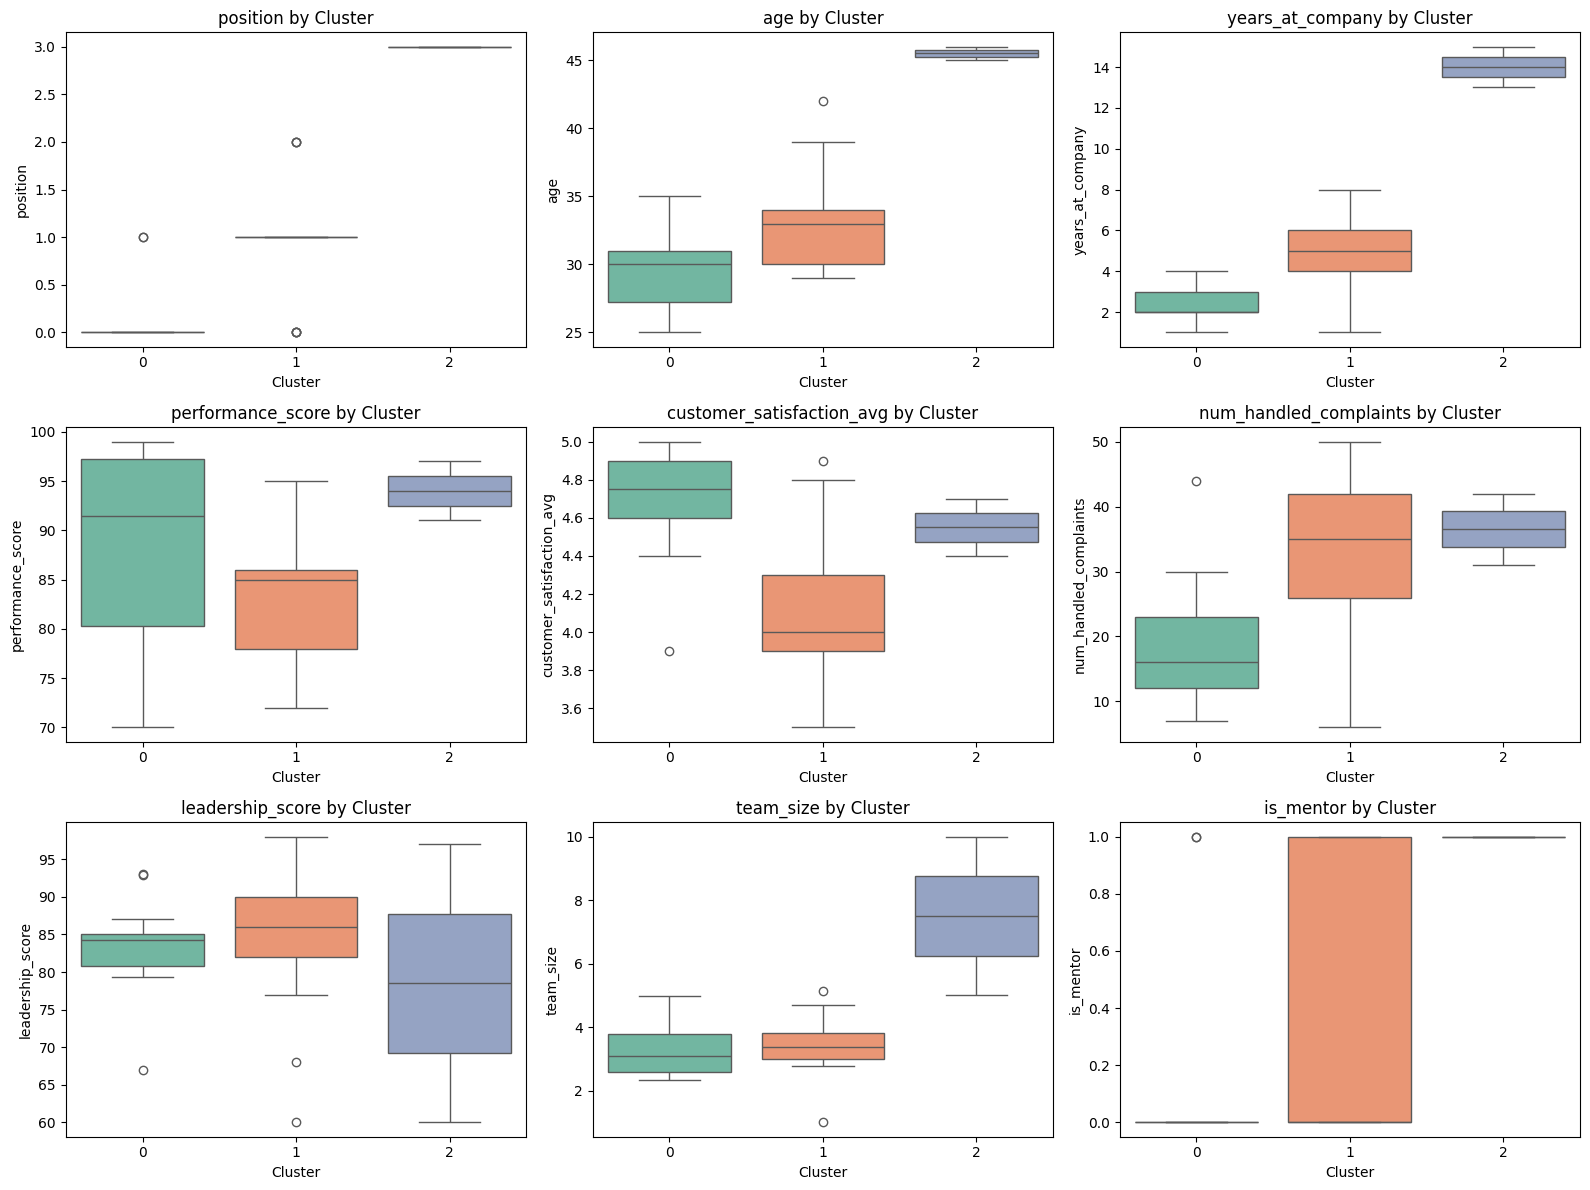

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 시각화
plt.figure(figsize=(16, 12))

for i, feature in enumerate(features, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(data=df, x='cluster', y=feature, palette='Set2')
    plt.title(f'{feature} by Cluster')
    plt.xlabel('Cluster')
    plt.ylabel(feature)

plt.tight_layout()
plt.show()


cluster0: 초급 실무자 중심 그룹
- age, years_at_company, team_size, is_mentor에서 가장 낮은 값들을 보여준다.

cluster1:중간 관리자형 그룹
- 대부분의 boxplot에서 중간값에 위치하며, is_mentor, team_size에서 일부 높게 분포하고 있다.

cluster2: 리더 그룹
- 나이가 많고, 근속이 길며, 모두 멘토이다. 성과점수가 가장 높고 민원 처리수가 가장 많다. 분포범위 자체가 다른 군집들과 차별적이다.

In [ ]:
df.head()

,position,age,years_at_company,performance_score,last_promotion_year,customer_satisfaction_avg,num_handled_complaints,leadership_score,team_size,is_mentor,gender_male,gender_female,cluster
0,1,34,4,98,2020,5.0,12,93.00,4.73,1,0,1,0
1,0,27,2,94,2019,4.8,30,85.12,3.70,0,1,0,0
2,0,30,1,98,2020,4.4,44,82.98,4.06,0,1,0,0
3,0,25,2,72,2022,5.0,16,84.71,2.82,0,0,1,0
4,1,32,5,76,2021,3.9,36,79.00,3.08,1,1,0,1


In [ ]:
uploaded = files.upload()
final_profiles = pd.read_excel('profiles.xlsx')
final_profiles['cluster'] = df['cluster']
final_profiles.head()

Saving profiles.xlsx to profiles (4).xlsx


,employee_id,name,branch,position,position_group,gender,age,years_at_company,performance_score,last_promotion_year,customer_satisfaction_avg,num_handled_complaints,leadership_score,team_size,is_mentor,cluster
0,H001,구민준,Tech운영부,대리,중간 관리자,여,34,4,98,2020,5.0,12,93.0,NaN,True,0
1,H002,김수진,글로벌서비스개발부,행원,실무자,남,27,2,94,2019,4.8,30,NaN,NaN,False,0
2,H003,김애은,금융서비스개발부,행원,실무자,남,30,1,98,2020,4.4,44,NaN,NaN,False,0
3,H004,김여리,Tech운영부,행원,실무자,여,25,2,72,2022,5.0,16,NaN,NaN,False,0
4,H005,김연지,자금세탁방지부,대리,중간 관리자,남,32,5,76,2021,3.9,36,79.0,NaN,True,1


In [ ]:
# 1. 엑셀로 저장 (df는 클러스터 컬럼이 붙은 데이터프레임이라고 가정)
final_profiles.to_excel('final_profiles.xlsx', index=False)

# 2. Colab에서 다운로드 링크 생성
from google.colab import files
files.download('final_profiles.xlsx')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>